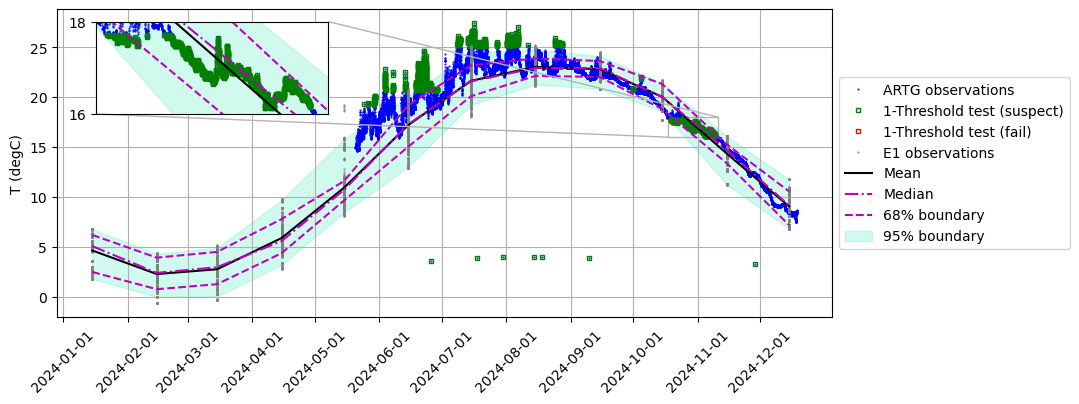

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# Parameters
var, inset = 'T', 1
Ayear = 2024
buoy, loc, Astn = 'ARTG', 'sfc', 'E1'
var_unit = {'T':'degC', 'S':'psu', 'DO':'mg/L'}
if loc == 'sfc':
    dpL, dpU = 0, 5
else:
    dpL, dpU = 23, 27

# Load datasets
df_b = pd.read_csv(f'{buoy}_{loc}_QAQC.csv')
df_b['TmStamp'] = pd.to_datetime(df_b['TmStamp'], format='%d-%b-%Y %H:%M:%S', errors='coerce')
df_b = df_b[(df_b['TmStamp'] >= f'{Ayear}-01-01') & (df_b['TmStamp'] <  f'{Ayear+1}-01-01')]

df_s = pd.read_csv(f'DEEP_{Astn}_WQ_QAQC.csv')
df_s['time'] = pd.to_datetime(df_s['time'], errors='coerce')
df_s = df_s[(df_s['depth'] >= dpL) & (df_s['depth'] < dpU) & (df_s[f'{var}_Q'] == 1)]

# Plot buoy data
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_b['TmStamp'], df_b[f'{var}_data'], 'b.', markersize=1, label=f'{buoy} observations')

# Highlight outliers
Q = df_b[f'{var}_Q']
if inset == 1:
    iu0 = np.where((Q // 10000) == 3)[0]
    ax.plot(df_b['TmStamp'].iloc[iu0], df_b[f'{var}_data'].iloc[iu0], 'gs', markersize=3, markerfacecolor='none', label='1-Threshold test (suspect)')
    iu1 = np.where((Q // 10000) == 4)[0]
    ax.plot(df_b['TmStamp'].iloc[iu1], df_b[f'{var}_data'].iloc[iu1], 'rs', markersize=3, markerfacecolor='none', label='1-Threshold test (fail)')
else:
    iu2 = np.where(((Q // 1000) % 10) == 4)[0]
    ax.plot(df_b['TmStamp'].iloc[iu2], df_b[f'{var}_data'].iloc[iu2], 'ro', markersize=4, markerfacecolor='none', label='2-JumpLim test (fail)')
    iu3 = np.where(((Q // 100) % 10) == 4)[0]
    ax.plot(df_b['TmStamp'].iloc[iu3], df_b[f'{var}_data'].iloc[iu3], 'y^', markersize=6, markerfacecolor='none', label='3-Gap test (fail)')
    iu4 = np.where(((Q // 10) % 10) == 4)[0]
    ax.plot(df_b['TmStamp'].iloc[iu4], df_b[f'{var}_data'].iloc[iu4], 'gD', markersize=6, markerfacecolor='none', label='4-PresRng test (fail)')
    iu5 = np.where((Q % 10) == 4)[0]
    ax.plot(df_b['TmStamp'].iloc[iu5], df_b[f'{var}_data'].iloc[iu5], 'rx',  markersize=4, markerfacecolor='none', label='5-Spike test (fail)')

# Compare with station climatology data
dt_s = pd.to_datetime([datetime(Ayear, m, 15) for m in df_s['time'].dt.month])
ax.plot(dt_s, df_s[f'{var}_data'], '.', color=[0.5, 0.5, 0.5], markersize=1, label=f'{Astn} observations')

# Compute station climatology statistics by month
bdmean, bd50 = np.zeros(12), np.zeros(12)
bd68L, bd68U = np.zeros(12), np.zeros(12)
bd95L, bd95U = np.zeros(12), np.zeros(12)

for nm in range(1, 13):
    idx = df_s[df_s['time'].dt.month == nm][f'{var}_data'].dropna()
    if len(idx) > 0:
        bdmean[nm-1], bd50[nm-1] = idx.mean(), np.percentile(idx, 50)
        bd68L[nm-1], bd68U[nm-1] = np.percentile(idx, 16), np.percentile(idx, 84)
        bd95L[nm-1], bd95U[nm-1] = np.percentile(idx, 2.5), np.percentile(idx, 97.5)

# Plot climatology lines and 95% patch
dt = pd.to_datetime([datetime(Ayear, m, 15) for m in range(1, 13)])
ax.plot(dt, bdmean, 'k-', label='Mean')
ax.plot(dt, bd50,  'm-.', label='Median')
ax.plot(dt, bd68L, 'm--', label='68% boundary')
ax.plot(dt, bd68U, 'm--', label='_nolegend_')
ax.fill_between(dt, bd95L, bd95U, color=[0.1, 0.9, 0.7], alpha=0.2, edgecolor=[0.1, 0.9, 0.7], label='95% boundary')

if inset == 1:
    # Create inset axes
    axins = inset_axes(ax, width='100%', height='100%', bbox_to_anchor=(0.05, 0.66, 0.3, 0.3), bbox_transform=ax.transAxes, loc=10)  # 0.05, 0.66
    axins.plot(df_b['TmStamp'], df_b[f'{var}_data'], 'b.', markersize=1)
    axins.plot(df_b['TmStamp'].iloc[iu0], df_b[f'{var}_data'].iloc[iu0], 'gs', markersize=3, markerfacecolor='none')
    axins.plot(df_b['TmStamp'].iloc[iu1], df_b[f'{var}_data'].iloc[iu1], 'rs', markersize=3, markerfacecolor='none')
    axins.plot(dt_s, df_s[f'{var}_data'], '.', color=[0.5, 0.5, 0.5], markersize=1)
    axins.plot(dt, bdmean, 'k-')
    axins.plot(dt, bd50,  'm-.')
    axins.plot(dt, bd68L, 'm--')
    axins.plot(dt, bd68U, 'm--')
    axins.fill_between(dt, bd95L, bd95U, color=[0.1, 0.9, 0.7], alpha=0.2, edgecolor=[0.1, 0.9, 0.7])

    # Set zoom region
    axins.set_xlim(datetime(2024, 10, 18), datetime(2024, 11, 11))
    axins.set_ylim(16, 18)
    axins.set_xticks([])
    axins.set_yticks([axins.get_ylim()[0], axins.get_ylim()[1]])

    # Draw lines connecting zoom region to main plot
    mark_inset(ax, axins, loc1=1, loc2=3, fc='none', ec='0.7')

xticks = pd.date_range(f'{Ayear}-01-01', f'{Ayear}-12-01', freq='MS')
ax.set_xticks(xticks)
plt.setp(ax.get_xticklabels(), rotation=45)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel(f'{var} ({var_unit[var]})')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.grid(True)

# plt.savefig(f'{buoy}_{loc}_{var}_{inset}.png', dpi=1200, format='png', bbox_inches='tight')
plt.show()

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Parameters
var = 'T'
buoy, loc, Astn = 'ARTG', 'sfc', 'E1'
var_unit = {'T':'degC', 'S':'psu', 'DO':'mg/L'}
if loc == 'sfc':
    dpL, dpU = 0, 5
else:
    dpL, dpU = 23, 27

# Load datasets
df_b = pd.read_csv(f'{buoy}_{loc}_QAQC.csv')
df_b['TmStamp'] = pd.to_datetime(df_b['TmStamp'], format='%d-%b-%Y %H:%M:%S', errors='coerce')
df_b = df_b[df_b['TmStamp'] < '2025-01-01']
df_b = df_b.sort_values('TmStamp').set_index('TmStamp')

df_s = pd.read_csv(f'DEEP_{Astn}_WQ_QAQC.csv')
df_s['time'] = pd.to_datetime(df_s['time'], errors='coerce')
df_s = df_s[(df_s['depth'] >= dpL) & (df_s['depth'] < dpU) & (df_s[f'{var}_Q'] != 4)]
df_s = df_s.sort_values('time').set_index('time')

# Clean datasets
df_b = df_b.loc[(df_b[f'{var}_Q'] // 10000) != 4]

# Compute yearly stats of buoy data
yr_stats = []
for yr, dty in df_b.groupby(df_b.index.year):
    rmean = dty[f'{var}_data'].rolling('7D', center=True).mean()
    t_peak = rmean.idxmax() if var == 'T' else rmean.idxmin()

    wTb = dty.loc[t_peak - pd.Timedelta(days=14): t_peak + pd.Timedelta(days=14)]
    yr_stats.append({
        'time': t_peak,
        'mean': wTb[f'{var}_data'].mean(),
        'std': wTb[f'{var}_data'].std()
    })
yr_stats = pd.DataFrame(yr_stats)

# Compute yearly extreme of ship survey data
yr_extremes = []
for yr, dty in df_s.groupby(df_s.index.year):
    if var == 'T':
        iu, val = dty[f'{var}_data'].idxmax(), dty[f'{var}_data'].max()
    else:
        iu, val = dty[f'{var}_data'].idxmin(), dty[f'{var}_data'].min()
    yr_extremes.append({
        'time': iu,
        'value': val
    })
yr_extremes = pd.DataFrame(yr_extremes)

# Convert timestamps to decimal years
t_buoy = yr_stats['time'].dt.year + (yr_stats['time'].dt.dayofyear - 1) / 365.25
x_buoy = sm.add_constant(t_buoy)
t_stn = yr_extremes['time'].dt.year + (yr_extremes['time'].dt.dayofyear - 1) / 365.25
x_stn = sm.add_constant(t_stn)

# Weighted least squares fit
weights = 1.0 / yr_stats['std']**2
wls = sm.WLS(yr_stats['mean'], x_buoy, weights=weights).fit()

# Prediction + CI
pred = wls.get_prediction(x_stn)
ci = pred.conf_int(alpha=0.05)

print(wls.summary())

                            WLS Regression Results                            
Dep. Variable:                   mean   R-squared:                       0.074
Model:                            WLS   Adj. R-squared:                 -0.018
Method:                 Least Squares   F-statistic:                    0.8037
Date:                Sat, 21 Mar 2026   Prob (F-statistic):              0.391
Time:                        15:02:40   Log-Likelihood:                -9.5309
No. Observations:                  12   AIC:                             23.06
Df Residuals:                      10   BIC:                             24.03
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -64.9282     99.014     -0.656      0.5

c:\Users\zhr19002\AppData\Local\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=12
  res = hypotest_fun_out(*samples, **kwds)


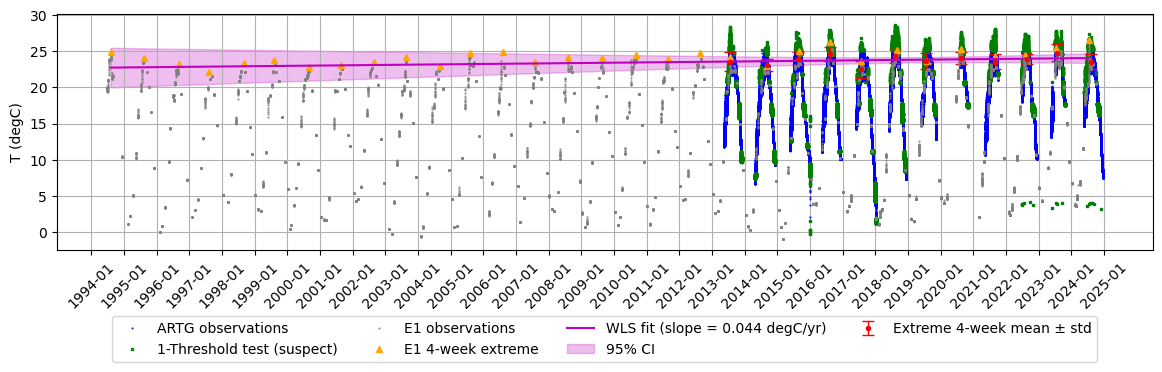

In [3]:
# Plot buoy data
plt.figure(figsize=(12, 4))
plt.plot(df_b.index, df_b[f'{var}_data'], 'b.', markersize=1, label=f'{buoy} observations')
iu = np.where((df_b[f'{var}_Q'] // 10000) == 3)[0]
plt.plot(df_b.index[iu], df_b[f'{var}_data'].iloc[iu], 'gs', markersize=2, markerfacecolor='none', label='1-Threshold test (suspect)')

# Plot yearly peak 4-week error bars
plt.errorbar(yr_stats['time'], yr_stats['mean'], yerr=yr_stats['std'],
    fmt='ro', markersize=3, capsize=4, elinewidth=1, label='Extreme 4-week mean ± std')

# Plot ship survey data
plt.plot(df_s.index, df_s[f'{var}_data'], '.', color='gray', markersize=1, label=f'{Astn} observations')

# Plot yearly peak 4-week max value
plt.plot(yr_extremes['time'], yr_extremes['value'], '^', color='orange', markersize=5, label=f'{Astn} 4-week extreme')

# WLS fit + CI + extrapolation
plt.plot(yr_extremes['time'], pred.predicted_mean, 'm-', label=f'WLS fit (slope = {wls.params.iloc[1]:.3f} {var_unit[var]}/yr)')
plt.fill_between(yr_extremes['time'], ci[:, 0], ci[:, 1], color='m', alpha=0.25, label='95% CI')

year_start, year_end = df_s.index.year.min(), df_s.index.year.max()
xticks = [pd.Timestamp(f'{y}-01-01') for y in range(year_start, year_end + 2)]
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(xticks, rotation=45)
plt.ylabel(f'{var} ({var_unit[var]})')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=4)

plt.grid(True)
plt.tight_layout()
# plt.savefig(f'{buoy}_{loc}_{var}_trend.png', dpi=1200, format='png', bbox_inches='tight')
plt.show()